## JALANIN INI CUMA KALO ENVIRONMENTNYA DISPOSABLE (Remote Jupyter Server)

In [1]:
import shutil
import subprocess
from pathlib import Path
import os
import random
import json
from datetime import datetime, timezone

# Reduce allocator fragmentation for the large encoder activations and Adam
# state tensors. This must be set before PyTorch initializes CUDA.
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

'expandable_segments:True'

In [ ]:
subprocess.run(["uv", "add", "torch", "torchvision", "transformers==4.49.0", "gdown", "multilingual-clip", "pillow", "pandas", "scikit-learn", "tqdm", "torchinfo", "matplotlib"], cwd="/root/bukan-skripsi/notebooks/3rd_exp")

In [ ]:
# Optional: Install 7z if on Linux
subprocess.run(["apt", "install", "-y", "p7zip-full"])

In [2]:
cwd = Path.cwd().resolve()

# Jupyter normally starts in this notebook's directory, whereas the paired
# Python file is often launched from the repository root. Find the repository
# by its datasets directory instead of relying on a fixed number of parents.
project_root_dir = next(
    (path for path in (cwd, *cwd.parents) if (path / "datasets").is_dir()),
    cwd,
)
dataset_root_dir = project_root_dir / "datasets"

# Symlink or set dataset directory
dataset_dir = cwd / "dataset"
if not dataset_dir.exists():
    upstream_data_dir = dataset_root_dir / "MMSD2.0" / "data"
    if upstream_data_dir.exists():
        dataset_dir = upstream_data_dir
    else:
        # Clone if missing
        subprocess.run(["git", "clone", "--depth", "1", "--no-checkout", "https://github.com/Yanfiq/MMSD2.0.git", "dataset"])
        subprocess.run(["git", "sparse-checkout", "set", "data"], cwd=cwd / "dataset")
        subprocess.run(["git", "checkout", "main"], cwd=cwd / "dataset")
        data_dir = cwd / "dataset" / "data"
        if data_dir.exists():
            for item in data_dir.iterdir():
                shutil.move(str(item), str(cwd / "dataset" / item.name))
            data_dir.rmdir()

### Download MMSD2.0 Images & Whitelist (if not already downloaded)

In [ ]:
import gdown
# Avoid downloading and extracting the large image archive on every rerun.
# The metadata repository contains an empty dataset_image placeholder, so the
# directory existing by itself does not mean the archive was extracted.
image_dir = dataset_dir / "dataset_image"
if not image_dir.is_dir() or not any(image_dir.glob("*.jpg")):
    dataset_dir.mkdir(parents=True, exist_ok=True)
    gdown.download(url='https://drive.google.com/uc?id=1mK0Nf-jv_h2bgHUCRM4_EsdTiiitZ_Uj', output=str(dataset_dir) + "/", quiet=False)
    gdown.download(url='https://drive.google.com/uc?id=1AOWzlOz5hmdO39dEmzhQ4z_nabgzi7Tu', output=str(dataset_dir) + "/", quiet=False)
    gdown.download(url='https://drive.google.com/uc?id=1dJERrVlp7DlNSXk-uvbbG6Rv7uvqTOKd', output=str(dataset_dir) + "/", quiet=False)
    gdown.download(url='https://drive.google.com/uc?id=1pODuKC4gP6-QDQonG8XTqI8w8ds68mE3', output=str(dataset_dir) + "/", quiet=False)
    subprocess.run(
        ["7z", "x", str(dataset_dir / "dataset_image.zip"), f"-o{dataset_dir}"],
        check=True,
    )

## Hyperparameters & Configuration

In [3]:
class BlankObject:
    pass

params = BlankObject()
params.text_model_name = "M-CLIP/LABSE-Vit-L-14"
params.vision_model_name = "openai/clip-vit-large-patch14"
params.device = "cuda" if __import__("torch").cuda.is_available() else "cpu"
params.simple_linear = False
params.fuse_dim = 768        # M-CLIP project dim and ViT-L-14 visual projection dim
params.text_size = 768
params.image_size = 768
params.layers = 3
params.dropout_rate = 0.1
params.num_train_epochs = 10
params.train_batch_size = 8
params.dev_batch_size = 8
params.max_len = 77
params.learning_rate = 1e-4
params.label_count = 2
params.label_number = 2
params.output_dir = "./saved_models"
params.model = "sarcasm_model_mclip_v1"
params.seed = 42

# Dataset Loading & Preprocessing

In [4]:
import random
import pandas as pd
import numpy as np
from PIL import Image
from pathlib import Path
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoProcessor

# Make data ordering and parameter initialization repeatable. Exact numerical
# equality can still depend on the GPU, CUDA and PyTorch versions in use.
random.seed(params.seed)
np.random.seed(params.seed)
torch.manual_seed(params.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(params.seed)

In [5]:
json_path = dataset_dir / "text_json_id" / "dataset_translated_fixed.json"
df = pd.read_json(json_path, orient="records", dtype={"image_id": str, "label": int}).set_index("image_id")
df.head()

,text,label,split,text_translated
image_id,,,,
840006160660983809,<user> thanks for showing up for our appointme...,1,train,<user> Terima kasih sudah datang ke janji temu...
908913372199915520,haha .,1,train,haha .
916496521406726145,i love waiting <num> min for a cab - such shor...,1,train,Aku suka menunggu <num> menit untuk taksi — be...
916364004129304576,22 super funny quotes <user>,1,train,22 kutipan yang super lucu <pengguna>
853866052589154304,goog morning,1,train,Selamat pagi


In [ ]:
# # Filter out text-heavy images using whitelist
# # commented because for now i want to try training with all images, not just the whitelist
# whitelist_path = dataset_dir / "whitelist.txt"
# if whitelist_path.exists():
#     with open(whitelist_path, "r") as f:
#         whitelist = set(line.strip().replace(".jpg", "") for line in f if line.strip())
#     df = df[df.index.isin(whitelist)]

# print(f"Total samples after whitelist filtering: {len(df)}")
# print(df.describe())
# print(df.info())
# print(df.value_counts(['split', 'label']))

In [6]:
class MMSD2_id_dataset(Dataset):
    def __init__(self, dataframe, dataset_dir):
        self.data = dataframe.to_dict(orient="index")
        self.image_ids = list(self.data.keys())
        self.dataset_dir = Path(dataset_dir)
        for img_id in self.image_ids:
            self.data[img_id]["image_path"] = self.dataset_dir / "dataset_image" / f"{img_id}.jpg"

    def image_loader(self, img_id):
        img_path = self.data[img_id]["image_path"]
        return Image.open(img_path).convert("RGB")

    def text_loader(self, img_id):
        return self.data[img_id]["text_translated"]

    def __getitem__(self, index):
        img_id = self.image_ids[index]
        text = self.text_loader(img_id)
        image = self.image_loader(img_id)
        label = self.data[img_id]["label"]
        return text, image, label, img_id

    def __len__(self):
        return len(self.image_ids)

    @staticmethod
    def collate_func(batch_data):
        if len(batch_data) == 0:
            return [], [], [], []

        text_list = []
        image_list = []
        label_list = []
        id_list = []
        for instance in batch_data:
            text_list.append(instance[0])
            image_list.append(instance[1])
            label_list.append(instance[2])
            id_list.append(instance[3])
        return text_list, image_list, label_list, id_list

### Split Strategy: Default Upstream Split (Recommended)

In [7]:
train_dataset = MMSD2_id_dataset(df[df["split"] == "train"], dataset_dir)
val_dataset = MMSD2_id_dataset(df[df["split"] == "valid"], dataset_dir)
test_dataset = MMSD2_id_dataset(df[df["split"] == "test"], dataset_dir)

print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}, Test samples: {len(test_dataset)}")

Train samples: 19816, Val samples: 2410, Test samples: 2409


### (Alternative) Custom Stratified Split

In [ ]:
# indices = list(range(len(df)))
# labels = df.label
# train_indices, val_test_indices = train_test_split(indices, test_size=0.4, stratify=labels, random_state=42)
# labels_test_val = labels.iloc[val_test_indices].tolist()
# val_indices, test_indices = train_test_split(val_test_indices, test_size=0.5, stratify=labels_test_val, random_state=42)

# train_dataset = MMSD2_id_dataset(df.iloc[train_indices], dataset_dir)
# val_dataset = MMSD2_id_dataset(df.iloc[val_indices], dataset_dir)
# test_dataset = MMSD2_id_dataset(df.iloc[test_indices], dataset_dir)

# Model Architecture: Multilingual CLIP Multimodal Fusion

In [8]:
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import BertConfig, CLIPVisionModelWithProjection
from transformers.models.bert.modeling_bert import BertLayer
from multilingual_clip import pt_multilingual_clip
from sklearn import metrics
from tqdm import tqdm, trange

In [9]:
# Reset default device to standard CPU to prevent meta-device errors from previous kernel runs
if hasattr(torch, "set_default_device"):
    torch.set_default_device(None)

device = torch.device(params.device)
print(f"Using device: {device}")

Using device: cuda


In [10]:
class MultimodalEncoder(nn.Module):
    def __init__(self, config, layer_number):
        super(MultimodalEncoder, self).__init__()
        layer = BertLayer(config)
        self.layer = nn.ModuleList([copy.deepcopy(layer) for _ in range(layer_number)])

    def forward(self, hidden_states, attention_mask, output_all_encoded_layers=True):
        all_encoder_layers = []
        for layer_module in self.layer:
            hidden_states = layer_module(
                hidden_states,
                attention_mask,
                output_attentions=False,
            )[0]
            if output_all_encoded_layers:
                all_encoder_layers.append(hidden_states)
        if not output_all_encoded_layers:
            all_encoder_layers.append(hidden_states)
        return all_encoder_layers


class SarcasmModel(nn.Module):
    def __init__(self, args):
        super(SarcasmModel, self).__init__()
        self.args = args
        self.fuse_dim = getattr(args, "fuse_dim", 768)

        # 1. Multilingual Text Encoder (LaBSE + Linear Projection to shared space)
        self.mclip = pt_multilingual_clip.MultilingualCLIP.from_pretrained(args.text_model_name)
        self.text_encoder = self.mclip.transformer
        self.text_projection = self.mclip.LinearTransformation

        # 2. CLIP Vision Encoder (OpenAI ViT-L/14 with Projection to 768)
        self.vision_encoder = CLIPVisionModelWithProjection.from_pretrained(args.vision_model_name)

        # 3. Multimodal Cross-Attention Fusion
        self.config = BertConfig.from_pretrained("bert-base-uncased")
        self.config.hidden_size = self.fuse_dim
        self.config.num_attention_heads = 8
        self.trans = MultimodalEncoder(self.config, layer_number=args.layers)

        # 4. Unimodal projection heads
        if args.simple_linear:
            self.text_linear = nn.Linear(self.fuse_dim, self.fuse_dim)
            self.image_linear = nn.Linear(self.fuse_dim, self.fuse_dim)
        else:
            self.text_linear = nn.Sequential(
                nn.Linear(self.fuse_dim, self.fuse_dim),
                nn.Dropout(args.dropout_rate),
                nn.GELU()
            )
            self.image_linear = nn.Sequential(
                nn.Linear(self.fuse_dim, self.fuse_dim),
                nn.Dropout(args.dropout_rate),
                nn.GELU()
            )

        # 5. Classifiers & loss
        self.classifier_fuse = nn.Linear(self.fuse_dim, args.label_number)
        self.classifier_text = nn.Linear(self.fuse_dim, args.label_number)
        self.classifier_image = nn.Linear(self.fuse_dim, args.label_number)

        self.loss_fct = nn.CrossEntropyLoss()
        self.att = nn.Linear(self.fuse_dim, 1, bias=False)

    def forward(self, input_ids=None, attention_mask=None, pixel_values=None, labels=None, **kwargs):
        # Support dict input / kwargs
        if isinstance(input_ids, dict):
            kwargs = input_ids
            input_ids = kwargs.get('input_ids')
            attention_mask = kwargs.get('attention_mask')
            pixel_values = kwargs.get('pixel_values')
            if 'labels' in kwargs and labels is None:
                labels = kwargs['labels']

        # 1. Text Feature Extraction & Projection
        text_out = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        text_hidden_states = text_out.last_hidden_state  # [B, L_text, text_dim]
        text_embeds = self.text_projection(text_hidden_states)  # [B, L_text, fuse_dim]

        # Mean-pooled text feature (attention masked)
        text_att_expanded = attention_mask.unsqueeze(-1).to(text_embeds.dtype)
        text_pooled = (text_embeds * text_att_expanded).sum(dim=1) / text_att_expanded.sum(dim=1).clamp(min=1e-9)
        text_feature = self.text_linear(text_pooled)  # [B, fuse_dim]

        # 2. Vision Feature Extraction & Projection
        vision_out = self.vision_encoder(pixel_values=pixel_values, output_attentions=False)
        image_hidden_states = vision_out.last_hidden_state  # [B, L_img, vision_dim]
        image_embeds = self.vision_encoder.visual_projection(image_hidden_states)  # [B, L_img, fuse_dim]
        image_feature = self.image_linear(vision_out.image_embeds)  # [B, fuse_dim]

        # 3. Multimodal Token Concatenation & Cross-Attention
        num_img_tokens = image_embeds.shape[1]
        batch_size = input_ids.shape[0]

        input_embeds = torch.cat((image_embeds, text_embeds), dim=1)  # [B, L_img + L_text, fuse_dim]

        img_mask = torch.ones((batch_size, num_img_tokens), device=attention_mask.device, dtype=attention_mask.dtype)
        combined_mask = torch.cat((img_mask, attention_mask), dim=-1)  # [B, L_img + L_text]

        extended_mask = combined_mask.unsqueeze(1).unsqueeze(2)
        extended_mask = extended_mask.to(dtype=next(self.parameters()).dtype)
        extended_mask = (1.0 - extended_mask) * -10000.0

        fuse_hiddens = self.trans(input_embeds, extended_mask, output_all_encoded_layers=False)
        fuse_hiddens = fuse_hiddens[-1]  # [B, L_total, fuse_dim]

        # 4. Multimodal Pooled Representations
        new_image_feature = fuse_hiddens[:, 0, :]  # Visual CLS token [B, fuse_dim]
        new_text_tokens = fuse_hiddens[:, num_img_tokens:, :]  # Fused text tokens [B, L_text, fuse_dim]
        new_text_feature = (new_text_tokens * text_att_expanded).sum(dim=1) / text_att_expanded.sum(dim=1).clamp(min=1e-9)

        # 5. Adaptive Attention Fusion
        text_weight = self.att(new_text_feature)
        image_weight = self.att(new_image_feature)
        att = F.softmax(torch.cat((text_weight, image_weight), dim=-1), dim=-1)
        tw = att[:, 0:1]
        iw = att[:, 1:2]
        fuse_feature = tw * new_text_feature + iw * new_image_feature

        # 6. Classification
        logits_fuse = self.classifier_fuse(fuse_feature)
        logits_text = self.classifier_text(text_feature)
        logits_image = self.classifier_image(image_feature)

        fuse_score = F.softmax(logits_fuse, dim=-1)
        text_score = F.softmax(logits_text, dim=-1)
        image_score = F.softmax(logits_image, dim=-1)

        # An equal-weight ensemble of the three heads. Averaging preserves the
        # predicted class while returning a valid probability distribution.
        score = (fuse_score + text_score + image_score) / 3.0

        outputs = (score,)
        if labels is not None:
            loss_fuse = self.loss_fct(logits_fuse, labels)
            loss_text = self.loss_fct(logits_text, labels)
            loss_image = self.loss_fct(logits_image, labels)
            loss = loss_fuse + loss_text + loss_image
            outputs = (loss,) + outputs

        return outputs

# Evaluation & Metrics Helpers

In [11]:
def evaluate_acc_f1(
    params,
    model,
    device,
    data,
    tokenizer,
    processor,
    average='binary',
    pre=None,
    mode='test',
):
    data_loader = DataLoader(
        data,
        batch_size=params.dev_batch_size,
        collate_fn=MMSD2_id_dataset.collate_func,
        shuffle=False
    )
    n_correct, n_total = 0, 0
    t_targets_all, t_outputs_all = None, None

    model.eval()
    sum_loss = 0.0
    sum_step = 0

    with torch.no_grad():
        for i_batch, t_batch in enumerate(data_loader):
            text_list, image_list, label_list, id_list = t_batch
            text_inputs = tokenizer(
                text_list,
                padding='max_length',
                truncation=True,
                max_length=params.max_len,
                return_tensors="pt"
            ).to(device)
            image_inputs = processor(images=image_list, return_tensors="pt").to(device)
            labels = torch.tensor(label_list, dtype=torch.long).to(device)

            loss, t_outputs = model(
                input_ids=text_inputs['input_ids'],
                attention_mask=text_inputs['attention_mask'],
                pixel_values=image_inputs['pixel_values'],
                labels=labels
            )
            sum_loss += loss.item()
            sum_step += 1

            outputs = torch.argmax(t_outputs, -1)

            n_correct += (outputs == labels).sum().item()
            n_total += len(outputs)

            if t_targets_all is None:
                t_targets_all = labels
                t_outputs_all = outputs
            else:
                t_targets_all = torch.cat((t_targets_all, labels), dim=0)
                t_outputs_all = torch.cat((t_outputs_all, outputs), dim=0)

    avg_loss = sum_loss / max(sum_step, 1)
    if mode == 'test':
        print(f"Test Loss: {avg_loss:.4f}")
    else:
        print(f"Dev Loss: {avg_loss:.4f}")

    if pre is not None:
        with open(pre, 'w', encoding='utf-8') as fout:
            predict = t_outputs_all.cpu().numpy().tolist()
            label = t_targets_all.cpu().numpy().tolist()
            for pred_val, true_val in zip(predict, label):
                fout.write(f"{pred_val}\t{true_val}\n")

    acc = n_correct / max(n_total, 1)
    f1 = metrics.f1_score(t_targets_all.cpu(), t_outputs_all.cpu(), average=average, zero_division=0)
    precision = metrics.precision_score(t_targets_all.cpu(), t_outputs_all.cpu(), average=average, zero_division=0)
    recall = metrics.recall_score(t_targets_all.cpu(), t_outputs_all.cpu(), average=average, zero_division=0)

    return avg_loss, acc, f1, precision, recall

# Initialization & Training Setup

In [12]:
tokenizer = AutoTokenizer.from_pretrained(params.text_model_name)
processor = AutoProcessor.from_pretrained(params.vision_model_name)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=params.train_batch_size,
    collate_fn=MMSD2_id_dataset.collate_func,
    shuffle=True,
    generator=torch.Generator().manual_seed(params.seed),
)

model = SarcasmModel(params).to(device)
# Fused Adam avoids the large update temporaries created by the foreach and
# single-tensor implementations for these two large encoders.
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=params.learning_rate,
    fused=device.type == "cuda",
)

# Training Loop

In [13]:
max_acc = float('-inf')
run_output_dir = Path(params.output_dir) / params.model
run_output_dir.mkdir(parents=True, exist_ok=True)
metrics_path = run_output_dir / "metrics_history.json"

metrics_history = {
    "schema_version": 1,
    "model": params.model,
    "started_at": datetime.now(timezone.utc).isoformat(),
    "config": {
        "text_model_name": params.text_model_name,
        "vision_model_name": params.vision_model_name,
        "num_train_epochs": int(params.num_train_epochs),
        "train_batch_size": int(params.train_batch_size),
        "dev_batch_size": int(params.dev_batch_size),
        "learning_rate": float(params.learning_rate),
        "seed": int(params.seed),
    },
    "epochs": [],
    "test": None,
}


def save_metrics_history():
    """Atomically persist metrics so an interrupted run keeps prior epochs."""
    temporary_path = metrics_path.with_suffix(".json.tmp")
    with temporary_path.open("w", encoding="utf-8") as metrics_file:
        json.dump(metrics_history, metrics_file, indent=2, ensure_ascii=False)
        metrics_file.write("\n")
    temporary_path.replace(metrics_path)


save_metrics_history()

for i_epoch in trange(0, int(params.num_train_epochs), desc="Epoch", disable=False):
    sum_loss = 0.0
    sum_step = 0
    train_targets_all = []
    train_outputs_all = []

    iter_bar = tqdm(train_loader, desc=f"Epoch {i_epoch} Iter", disable=False)
    model.train()

    for step, batch in enumerate(iter_bar):
        text_list, image_list, label_list, id_list = batch

        text_inputs = tokenizer(
            text_list,
            padding='max_length',
            truncation=True,
            max_length=params.max_len,
            return_tensors="pt"
        ).to(device)
        image_inputs = processor(images=image_list, return_tensors="pt").to(device)
        labels = torch.tensor(label_list, dtype=torch.long).to(device)

        loss, score = model(
            input_ids=text_inputs['input_ids'],
            attention_mask=text_inputs['attention_mask'],
            pixel_values=image_inputs['pixel_values'],
            labels=labels
        )

        sum_loss += loss.item()
        sum_step += 1
        train_targets_all.append(labels.detach().cpu())
        train_outputs_all.append(torch.argmax(score.detach(), dim=-1).cpu())

        iter_bar.set_description(f"Epoch {i_epoch} Loss: {loss.item():.4f}")
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    avg_train_loss = sum_loss / max(sum_step, 1)
    train_targets_all = torch.cat(train_targets_all)
    train_outputs_all = torch.cat(train_outputs_all)
    train_acc = metrics.accuracy_score(train_targets_all, train_outputs_all)
    train_f1 = metrics.f1_score(
        train_targets_all, train_outputs_all, average='binary', zero_division=0
    )
    train_precision = metrics.precision_score(
        train_targets_all, train_outputs_all, average='binary', zero_division=0
    )
    train_recall = metrics.recall_score(
        train_targets_all, train_outputs_all, average='binary', zero_division=0
    )
    print(f"\n--- Epoch {i_epoch} Summary ---")
    print(
        f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Train F1: {train_f1:.4f} | Train Precision: {train_precision:.4f} | "
        f"Train Recall: {train_recall:.4f}"
    )

    dev_loss, dev_acc, dev_f1, dev_precision, dev_recall = evaluate_acc_f1(
        params, model, device, val_dataset, tokenizer, processor, mode='dev'
    )
    print(f"Dev Loss: {dev_loss:.4f} | Dev Acc: {dev_acc:.4f} | Dev F1: {dev_f1:.4f} | Dev Precision: {dev_precision:.4f} | Dev Recall: {dev_recall:.4f}")

    # Select and save checkpoints using validation data only.
    is_best = dev_acc > max_acc
    if is_best:
        max_acc = dev_acc
        model_to_save = model.module if hasattr(model, "module") else model
        torch.save(model_to_save.state_dict(), run_output_dir / 'model.pt')
        print(f"[*] New best validation accuracy! Saved model checkpoint to {run_output_dir}")

    metrics_history["epochs"].append({
        "epoch": i_epoch + 1,
        "train_loss": float(avg_train_loss),
        "train_acc": float(train_acc),
        "train_f1": float(train_f1),
        "train_precision": float(train_precision),
        "train_recall": float(train_recall),
        "dev_loss": float(dev_loss),
        "dev_acc": float(dev_acc),
        "dev_f1": float(dev_f1),
        "dev_precision": float(dev_precision),
        "dev_recall": float(dev_recall),
        "learning_rate": float(optimizer.param_groups[0]["lr"]),
        "is_best": bool(is_best),
    })
    save_metrics_history()
    print(f"Metrics saved to {metrics_path}")

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# Evaluate the test set once, using the checkpoint selected on validation data.
best_model_path = run_output_dir / 'model.pt'
if best_model_path.exists():
    model.load_state_dict(torch.load(best_model_path, map_location=device, weights_only=True))
    test_loss, test_acc, test_f1, test_precision, test_recall = evaluate_acc_f1(
        params, model, device, test_dataset, tokenizer, processor, average='macro', mode='test'
    )
    _, _, test_f1_micro, test_precision_micro, test_recall_micro = evaluate_acc_f1(
        params, model, device, test_dataset, tokenizer, processor, average='micro', mode='test'
    )
    print(f"Macro Test -> Acc: {test_acc:.4f} | F1: {test_f1:.4f} | Prec: {test_precision:.4f} | Rec: {test_recall:.4f}")
    print(f"Micro Test -> F1: {test_f1_micro:.4f} | Prec: {test_precision_micro:.4f} | Rec: {test_recall_micro:.4f}")
    metrics_history["test"] = {
        "evaluated_at": datetime.now(timezone.utc).isoformat(),
        "loss": float(test_loss),
        "macro": {
            "accuracy": float(test_acc),
            "f1": float(test_f1),
            "precision": float(test_precision),
            "recall": float(test_recall),
        },
        "micro": {
            "f1": float(test_f1_micro),
            "precision": float(test_precision_micro),
            "recall": float(test_recall_micro),
        },
    }
    metrics_history["completed_at"] = datetime.now(timezone.utc).isoformat()
    save_metrics_history()
else:
    print("No best checkpoint was saved; skipping test evaluation.")

Epoch 0 Loss: 2.1362: 100%|██████████| 2477/2477 [33:51<00:00,  1.22it/s]



--- Epoch 0 Summary ---
Train Loss: 2.0987 | Train Acc: 0.5207 | Train F1: 0.4337 | Train Precision: 0.5054 | Train Recall: 0.3798
Dev Loss: 2.0909
Dev Loss: 2.0909 | Dev Acc: 0.4324 | Dev F1: 0.6037 | Dev Precision: 0.4324 | Dev Recall: 1.0000
[*] New best validation accuracy! Saved model checkpoint to saved_models/sarcasm_model_mclip_v1
Metrics saved to saved_models/sarcasm_model_mclip_v1/metrics_history.json


Epoch 1 Loss: 2.1029: 100%|██████████| 2477/2477 [33:58<00:00,  1.21it/s]



--- Epoch 1 Summary ---
Train Loss: 2.0851 | Train Acc: 0.5155 | Train F1: 0.3839 | Train Precision: 0.4979 | Train Recall: 0.3123
Dev Loss: 2.0818
Dev Loss: 2.0818 | Dev Acc: 0.5676 | Dev F1: 0.0000 | Dev Precision: 0.0000 | Dev Recall: 0.0000


Epoch:  20%|██        | 2/10 [1:12:51<4:51:35, 2186.97s/it]

...

Epoch 9 Loss: 1.9629: 100%|██████████| 2477/2477 [33:40<00:00,  1.23it/s]



--- Epoch 9 Summary ---
Train Loss: 2.0695 | Train Acc: 0.5579 | Train F1: 0.3435 | Train Precision: 0.6083 | Train Recall: 0.2393


Epoch: 100%|██████████| 10/10 [5:59:35<00:00, 2157.51s/it]

Dev Loss: 2.0531
Dev Loss: 2.0531 | Dev Acc: 0.5842 | Dev F1: 0.2316 | Dev Precision: 0.5763 | Dev Recall: 0.1449
Metrics saved to saved_models/sarcasm_model_mclip_v1/metrics_history.json


Test Loss: 2.0428
Test Loss: 2.0428
Macro Test -> Acc: 0.6227 | F1: 0.5870 | Prec: 0.6145 | Rec: 0.5933
Micro Test -> F1: 0.6227 | Prec: 0.6227 | Rec: 0.6227


# Evaluation

Training history plot saved to saved_models/sarcasm_model_mclip_v1/metrics_history.png


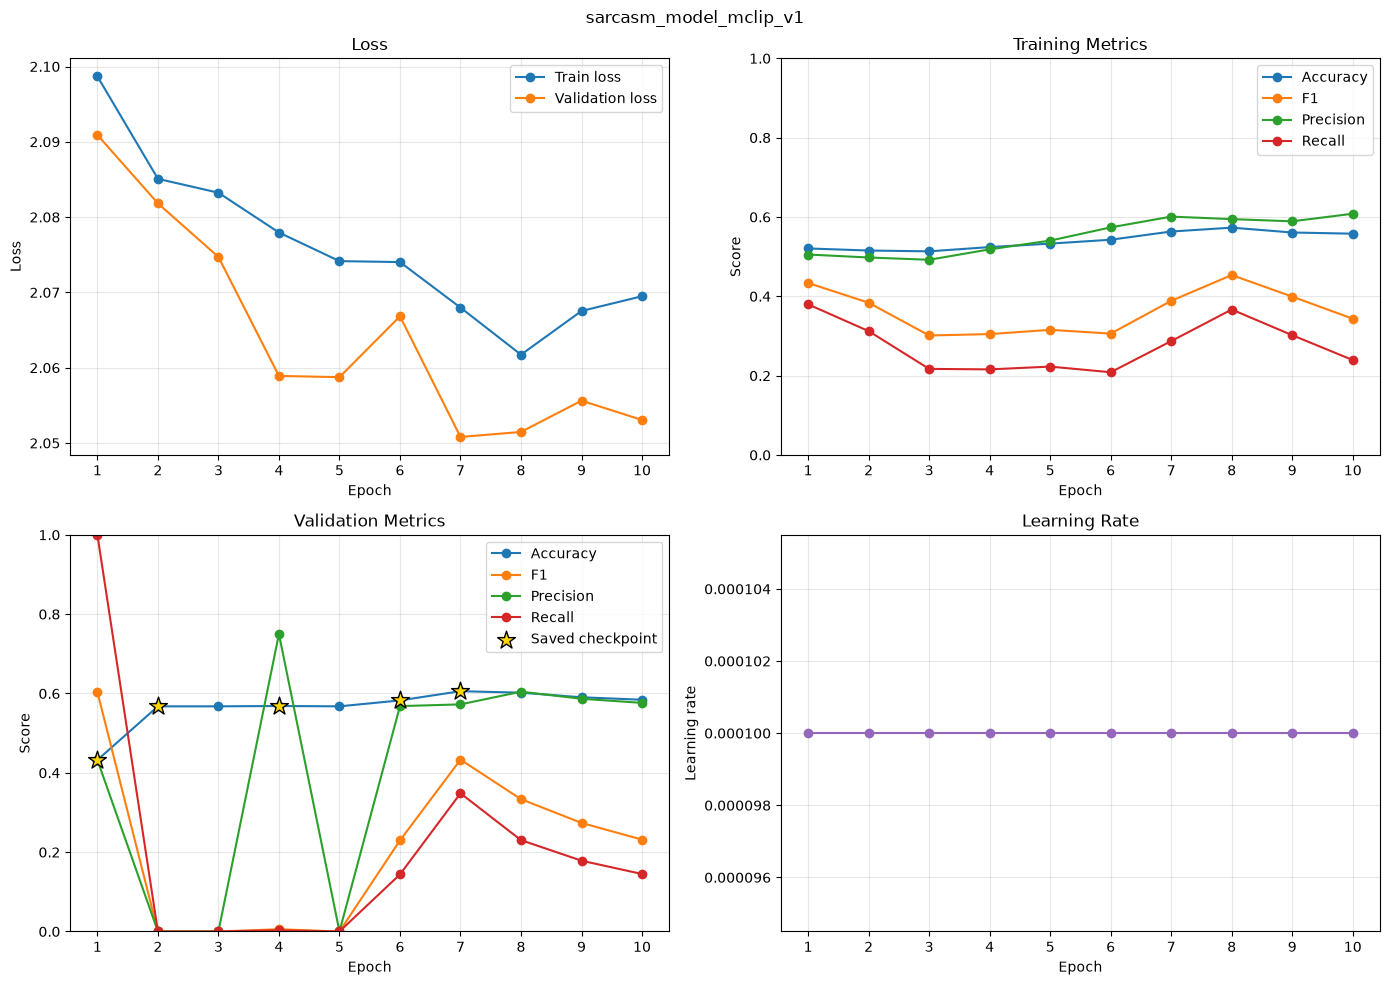

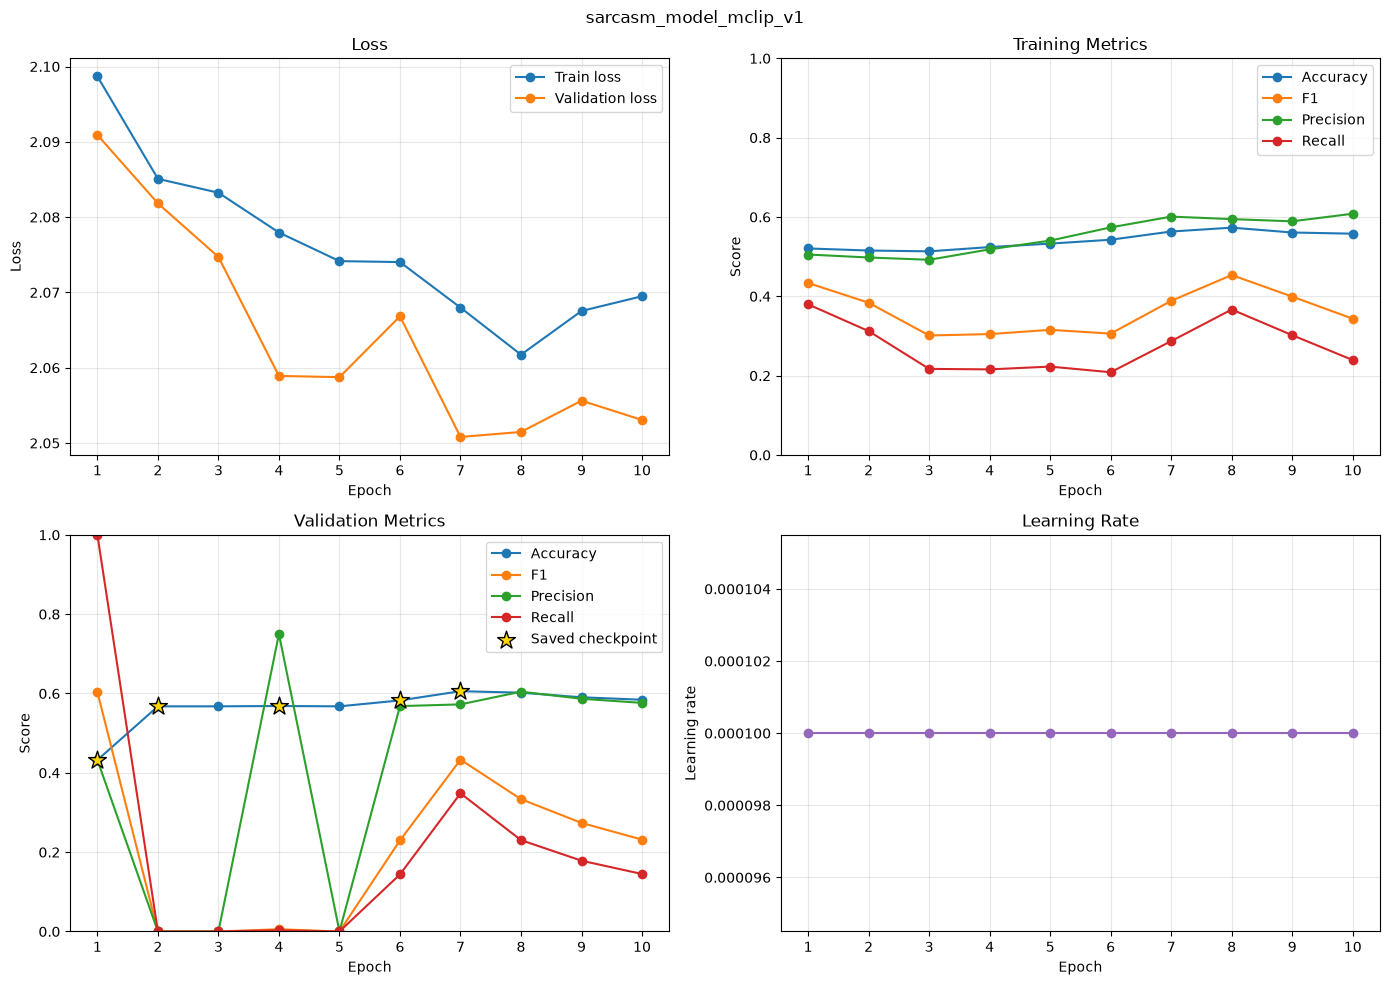

In [14]:
import matplotlib.pyplot as plt


def plot_metrics_history(history_path, show=True):
    """Plot per-epoch metrics from JSON and save the graph beside it."""
    history_path = Path(history_path)
    with history_path.open("r", encoding="utf-8") as metrics_file:
        history = json.load(metrics_file)

    epochs_history = history.get("epochs", [])
    if not epochs_history:
        print(f"No epoch metrics found in {history_path}")
        return None

    epochs = [entry["epoch"] for entry in epochs_history]
    best_entries = [entry for entry in epochs_history if entry.get("is_best")]

    figure, axes = plt.subplots(2, 2, figsize=(14, 10))
    loss_axis, train_axis, validation_axis, learning_rate_axis = axes.flat

    loss_axis.plot(
        epochs,
        [entry["train_loss"] for entry in epochs_history],
        marker="o",
        label="Train loss",
    )
    loss_axis.plot(
        epochs,
        [entry["dev_loss"] for entry in epochs_history],
        marker="o",
        label="Validation loss",
    )
    loss_axis.set_title("Loss")
    loss_axis.set_ylabel("Loss")
    loss_axis.legend()

    training_metrics = {
        "Accuracy": "train_acc",
        "F1": "train_f1",
        "Precision": "train_precision",
        "Recall": "train_recall",
    }
    for label, key in training_metrics.items():
        train_axis.plot(
            epochs,
            [entry[key] for entry in epochs_history],
            marker="o",
            label=label,
        )
    train_axis.set_title("Training Metrics")
    train_axis.set_ylabel("Score")
    train_axis.set_ylim(0.0, 1.0)
    train_axis.legend()

    validation_metrics = {
        "Accuracy": "dev_acc",
        "F1": "dev_f1",
        "Precision": "dev_precision",
        "Recall": "dev_recall",
    }
    for label, key in validation_metrics.items():
        validation_axis.plot(
            epochs,
            [entry[key] for entry in epochs_history],
            marker="o",
            label=label,
        )
    if best_entries:
        validation_axis.scatter(
            [entry["epoch"] for entry in best_entries],
            [entry["dev_acc"] for entry in best_entries],
            marker="*",
            s=180,
            color="gold",
            edgecolor="black",
            label="Saved checkpoint",
            zorder=3,
        )
    validation_axis.set_title("Validation Metrics")
    validation_axis.set_ylabel("Score")
    validation_axis.set_ylim(0.0, 1.0)
    validation_axis.legend()

    learning_rate_axis.plot(
        epochs,
        [entry["learning_rate"] for entry in epochs_history],
        marker="o",
        color="tab:purple",
    )
    learning_rate_axis.set_title("Learning Rate")
    learning_rate_axis.set_ylabel("Learning rate")

    for axis in axes.flat:
        axis.set_xlabel("Epoch")
        axis.set_xticks(epochs)
        axis.grid(True, alpha=0.3)

    figure.suptitle(history.get("model", "Training History"))
    figure.tight_layout()

    figure_path = history_path.with_name("metrics_history.png")
    figure.savefig(figure_path, dpi=160, bbox_inches="tight")
    print(f"Training history plot saved to {figure_path}")

    if show:
        plt.show()
    else:
        plt.close(figure)
    return figure


plot_metrics_history(metrics_path)